# 건강검진 데이터 분석

In [1]:
# 경고 메시지 무시
import warnings
warnings.filterwarnings(action='ignore') 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# plt.rc('font', family='malgun gothic')
# plt.rcParams['axes.unicode_minus']=False  # '- 표시
plt.rc('font',family='D2CodingLigature Nerd Font')

| 컬럼            | 의미                    |
| ------------- | -------------------- |
| no            | 개인 ID                |
| city_code     | 지역 코드                |
| gender        | 성별 (1=남, 2=여       ) |
| age_code      | 연령대 코드               |
| height        | 키 (cm)               |
| weight        | 몸무게 (kg)             |
| waist         | 허리둘레                 |
| systolic      | 수축기 혈압               |
| diastolic     | 이완기 혈압               |
| blood_sugar   | 공복 혈당                |
| cholesterol   | 총 콜레스테롤              |
| triglycerides | 중성지방                 |
| HDL           | 좋은 콜레스테롤             |
| LDL           | 나쁜 콜레스테롤             |
| hemoglobin    | 혈색소                  |
| serum         | 혈청 크레아티닌           |
| smoking       | 흡연 여부                |
| drinking      | 음주 여부                |

In [2]:
df = pd.read_excel('../../data/data1.xlsx')
df.head()

,no,city_code,gender,age_code,height,weight,waist,systolic,diastolic,blood_sugar,cholesterol,triglycerides,HDL,LDL,hemoglobin,serum,smoking,drinking
0,1,36,1,9,165,60,72.1,127,79,90,188,58,58.0,118,15.0,1.1,1,0
1,5,41,2,12,155,50,75.2,144,89,110,220,171,53.0,133,12.4,0.7,1,0
2,6,27,1,9,185,85,94.0,114,72,86,234,183,50.0,147,16.4,1.1,3,1
3,7,44,1,9,165,80,93.0,112,73,250,119,265,26.0,40,15.7,0.7,3,1
4,9,41,2,17,150,50,82.0,136,65,104,177,61,63.0,101,13.3,0.7,1,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   no             3000 non-null   int64  
 1   city_code      3000 non-null   int64  
 2   gender         3000 non-null   int64  
 3   age_code       3000 non-null   int64  
 4   height         3000 non-null   int64  
 5   weight         3000 non-null   int64  
 6   waist          3000 non-null   float64
 7   systolic       3000 non-null   int64  
 8   diastolic      3000 non-null   int64  
 9   blood_sugar    3000 non-null   int64  
 10  cholesterol    3000 non-null   int64  
 11  triglycerides  3000 non-null   int64  
 12  HDL            3000 non-null   float64
 13  LDL            3000 non-null   int64  
 14  hemoglobin     3000 non-null   float64
 15  serum          3000 non-null   float64
 16  smoking        3000 non-null   int64  
 17  drinking       3000 non-null   int64  
dtypes: float

In [4]:
df.describe()

,no,city_code,gender,age_code,height,weight,waist,systolic,diastolic,blood_sugar,cholesterol,triglycerides,HDL,LDL,hemoglobin,serum,smoking,drinking
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,3836.096333,33.757667,1.499667,11.989667,160.700000,62.625000,82.223300,124.538333,76.500667,103.666333,198.853000,126.274667,56.429400,117.087333,14.162867,0.852867,1.529333,0.565667
std,2202.387389,12.519419,0.500083,2.277416,9.135343,12.119544,9.521987,14.718766,9.643910,23.834786,42.028104,67.187186,14.712668,37.909358,1.540632,0.352304,0.768550,0.495752
min,1.000000,11.000000,1.000000,9.000000,135.000000,30.000000,57.000000,78.000000,50.000000,58.000000,70.000000,14.000000,19.000000,13.000000,6.500000,0.050000,1.000000,0.000000
25%,1903.250000,27.000000,1.000000,10.000000,155.000000,55.000000,75.000000,114.000000,70.000000,91.000000,169.000000,77.000000,46.000000,90.750000,13.200000,0.700000,1.000000,0.000000
50%,3822.000000,41.000000,1.000000,12.000000,160.000000,60.000000,82.000000,124.000000,77.000000,99.000000,198.000000,111.000000,54.000000,116.000000,14.200000,0.800000,1.000000,1.000000
75%,5736.750000,44.000000,2.000000,13.000000,170.000000,70.000000,88.425000,134.000000,82.000000,109.000000,226.000000,158.000000,65.000000,142.000000,15.200000,1.000000,2.000000,1.000000
max,7659.000000,49.000000,2.000000,18.000000,190.000000,120.000000,128.000000,199.000000,114.000000,473.000000,387.000000,399.000000,125.000000,297.000000,19.400000,8.700000,3.000000,1.000000


In [5]:
df.isnull().sum()

no               0
city_code        0
gender           0
age_code         0
height           0
weight           0
waist            0
systolic         0
diastolic        0
blood_sugar      0
cholesterol      0
triglycerides    0
HDL              0
LDL              0
hemoglobin       0
serum            0
smoking          0
drinking         0
dtype: int64

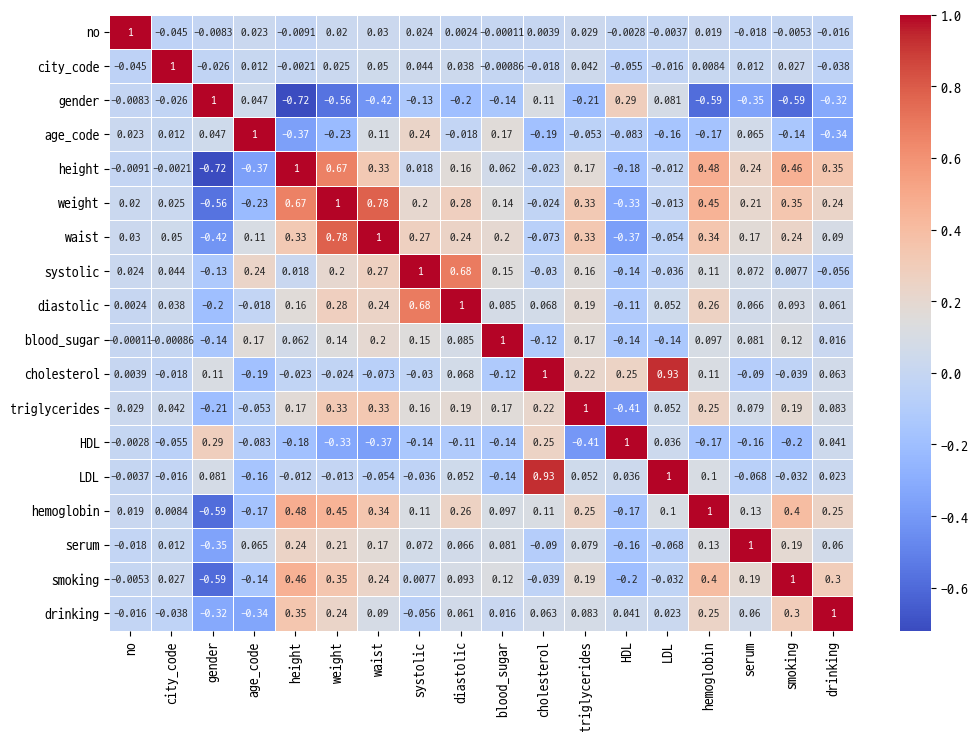

In [8]:
## 상관관계
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm", linewidths=0.5,
    annot_kws={"size":8}   # 숫자 글씨 크기
)

plt.show()

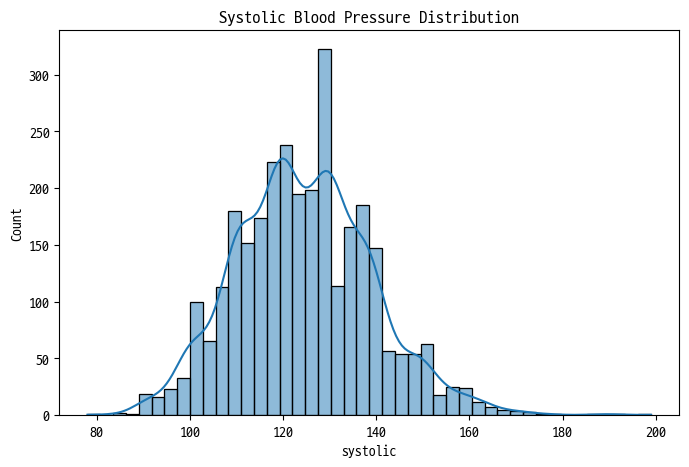

In [9]:
## 혈압 분포 시각화
plt.figure(figsize=(8,5))
sns.histplot(df['systolic'], kde=True)
plt.title("Systolic Blood Pressure Distribution")
plt.show()

In [11]:
## 성별에 따른 평균 혈당 비교
df.groupby("gender")["blood_sugar"].mean()

gender
1    107.112592
2    100.215477
Name: blood_sugar, dtype: float64

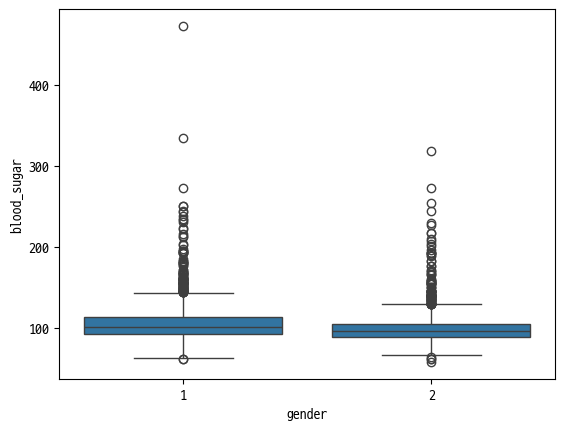

In [12]:
sns.boxplot(x="gender", y="blood_sugar", data=df)
plt.show()

In [13]:
## BMI 생성 (파생변수 만들기)
df["BMI"] = df["weight"] / (df["height"]/100)**2
df.head()

,no,city_code,gender,age_code,height,weight,waist,systolic,diastolic,blood_sugar,cholesterol,triglycerides,HDL,LDL,hemoglobin,serum,smoking,drinking,BMI
0,1,36,1,9,165,60,72.1,127,79,90,188,58,58.0,118,15.0,1.1,1,0,22.038567
1,5,41,2,12,155,50,75.2,144,89,110,220,171,53.0,133,12.4,0.7,1,0,20.811655
2,6,27,1,9,185,85,94.0,114,72,86,234,183,50.0,147,16.4,1.1,3,1,24.835646
3,7,44,1,9,165,80,93.0,112,73,250,119,265,26.0,40,15.7,0.7,3,1,29.384757
4,9,41,2,17,150,50,82.0,136,65,104,177,61,63.0,101,13.3,0.7,1,0,22.222222


* 저체중: 18.5 미만
* 정상: 18.5~23 
* 과체중: 23~25 
* 비만 1단계: 25~29.9 
* 비만 2단계: 30~34.9
* 고도비만(3단계): 35 이상

In [14]:
## BMI에 따른 비만 분류
def ob(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 23:
        return "Normal"
    elif bmi < 25:
        return "Overweight"
    else:
        return "Obese"    

df["obesity_level"] = df["BMI"].apply(ob)

df.head()

,no,city_code,gender,age_code,height,weight,waist,systolic,diastolic,blood_sugar,cholesterol,triglycerides,HDL,LDL,hemoglobin,serum,smoking,drinking,BMI,obesity_level
0,1,36,1,9,165,60,72.1,127,79,90,188,58,58.0,118,15.0,1.1,1,0,22.038567,Normal
1,5,41,2,12,155,50,75.2,144,89,110,220,171,53.0,133,12.4,0.7,1,0,20.811655,Normal
2,6,27,1,9,185,85,94.0,114,72,86,234,183,50.0,147,16.4,1.1,3,1,24.835646,Overweight
3,7,44,1,9,165,80,93.0,112,73,250,119,265,26.0,40,15.7,0.7,3,1,29.384757,Obese
4,9,41,2,17,150,50,82.0,136,65,104,177,61,63.0,101,13.3,0.7,1,0,22.222222,Normal


## 고혈압 여부 예측 모델

In [15]:
## 목표 변수 생성 (수축기 140 이상 = 고혈압)
df["hypertension"] = (df["systolic"] >= 140).astype(int)
df.head()

,no,city_code,gender,age_code,height,weight,waist,systolic,diastolic,blood_sugar,...,triglycerides,HDL,LDL,hemoglobin,serum,smoking,drinking,BMI,obesity_level,hypertension
0,1,36,1,9,165,60,72.1,127,79,90,...,58,58.0,118,15.0,1.1,1,0,22.038567,Normal,0
1,5,41,2,12,155,50,75.2,144,89,110,...,171,53.0,133,12.4,0.7,1,0,20.811655,Normal,1
2,6,27,1,9,185,85,94.0,114,72,86,...,183,50.0,147,16.4,1.1,3,1,24.835646,Overweight,0
3,7,44,1,9,165,80,93.0,112,73,250,...,265,26.0,40,15.7,0.7,3,1,29.384757,Obese,0
4,9,41,2,17,150,50,82.0,136,65,104,...,61,63.0,101,13.3,0.7,1,0,22.222222,Normal,0


In [17]:
## 데이터 분리
X = df.drop(["hypertension"], axis=1)
y = df["hypertension"]

# 원핫인코딩
X = pd.get_dummies(X, columns=["obesity_level"], drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
## 정규화
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
## 로지스틱 회귀
model = LogisticRegression()
model.fit(X_train, y_train)

# 계수
coef = model.coef_[0]

# 변수명과 같이 보기
feature_names = X.columns

for name, value in zip(feature_names, coef):
    print(f"{name}: {value:.4f}")

no: 0.1349
city_code: 0.1080
gender: 0.0296
age_code: 0.2220
height: 0.0023
weight: 0.1491
waist: 0.3094
systolic: 9.2154
diastolic: 0.2132
blood_sugar: -0.0085
cholesterol: -0.1631
triglycerides: -0.1636
HDL: -0.0369
LDL: 0.1689
hemoglobin: -0.0694
serum: 0.0008
smoking: 0.1134
drinking: -0.0175
BMI: -0.3136
obesity_level_Obese: -0.1121
obesity_level_Overweight: 0.0071
obesity_level_Underweight: -0.4430


In [22]:
## 새로운 환자 데이터 
new_data = pd.DataFrame([{
    "no": 8000,          # ID는 의미 없지만 X.columns 맞추기 위해 포함
    "city_code": 36,
    "gender": 1,
    "age_code": 12,
    "height": 175,
    "weight": 80,
    "waist": 85,
    "systolic": 130,
    "diastolic": 85,
    "blood_sugar": 105,
    "cholesterol": 210,
    "triglycerides": 160,
    "HDL": 50,
    "LDL": 130,
    "hemoglobin": 14.5,
    "serum": 1.1,
    "smoking": 1,
    "drinking": 0
}])

In [ ]:
## BMI 계산
new_data["BMI"] = new_data["weight"] / (new_data["height"]/100)**2

# ob함수는 이전에 작성
new_data["obesity_level"] = new_data["BMI"].apply(ob)

In [24]:
## 원핫인코딩 
new_data = pd.get_dummies(new_data, columns=["obesity_level"], drop_first=True)

In [25]:
# 데이터가 없는 컬럼은 0으로 채움
new_data = new_data.reindex(columns=X.columns, fill_value=0)

In [26]:
## 스케일링
new_data_scaled = scaler.transform(new_data)

## 예측
prediction = model.predict(new_data_scaled)
probability = model.predict_proba(new_data_scaled)

print("고혈압 여부:", prediction[0])
print("고혈압 확률:", probability[0][1])

고혈압 여부: 0
고혈압 확률: 0.002758991815086491


<Axes: xlabel='hypertension', ylabel='BMI'>

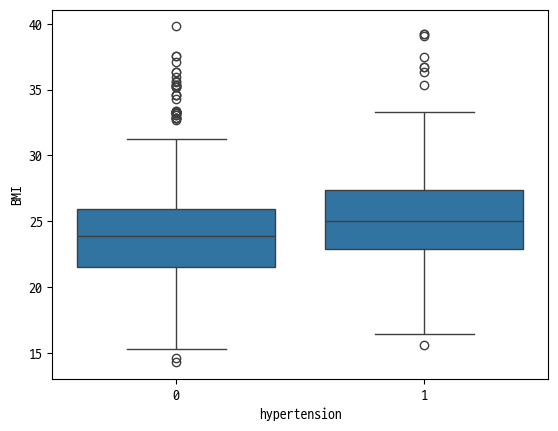

In [27]:
## BMI와 고혈압 관계
sns.boxplot(x="hypertension", y="BMI", data=df)

<Axes: xlabel='age_code', ylabel='hypertension'>

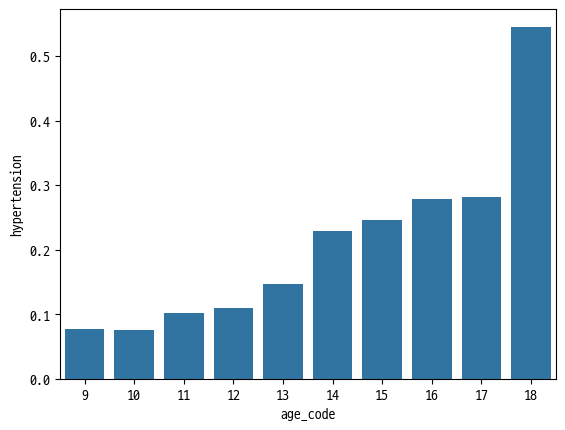

In [30]:
## 연령대별 고혈압 확률

sns.barplot(x="age_code", y="hypertension", data=df, ci=None)